https://dados.gov.br/dados/conjuntos-dados/cadastro-nacional-de-obras-cno

In [5]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [6]:
def formatar_escala(valor, pos=None):
    """
    Formata o número para k (milhares), M (milhões) ou B (bilhões).
    """
    if valor >= 1e9:   # Maior ou igual a 1 Bilhão
        return f'{valor * 1e-9:.1f}B'
    elif valor >= 1e6: # Maior ou igual a 1 Milhão
        return f'{valor * 1e-6:.1f}M'
    elif valor >= 1e3: # Maior ou igual a 1 Milhar
        return f'{valor * 1e-3:.1f}k'
    else:
        return str(int(valor))

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
import os

In [9]:
df_cno = pd.read_csv('../dados/raw/cno.csv', encoding='latin-1')

/var/folders/m6/5gldbqjd7y97574965jjjdsw0000gn/T/ipykernel_48889/3420878240.py:1: DtypeWarning: Columns (0: CEP, 1: Código do municipio) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cno = pd.read_csv('../dados/raw/cno.csv', encoding='latin-1')


In [10]:
df_cno.head()

,CNO,Código do Pais,Nome do pais,Data de início,Data de inicio da responsabilidade,Data de registro,CNO vinculado,CEP,NI do responsável,Qualificação do responsavel,Nome,Código do municipio,Nome do município,Tipo de logradouro,Logradouro,Número do logradouro,Bairro,Estado,Caixa Postal,Complemento,Unidade de medida,Área total,Situação,Data da situação,Nome empresarial,Código de localização
0,10010092278,105,BRASIL,1992-02-20,1992-02-20,2022-05-17,NaN,71215207,2.688984e+12,57,M H TECNOLOGIA LTDA,9701,BRASÍLIA,OUTROS,SOF SUL QUADRA 1 CONJUNTO B,SN,ZONA INDUSTRIAL (GUARA),DF,NaN,LOTES 3/5,m2,412.00,2,2002-11-30,M H TECNOLOGIA LTDA,NaN
1,10010144970,105,BRASIL,1997-12-29,1997-12-29,2023-05-22,NaN,73310303,3.677093e+13,70,SANTA PAULA ENGENHARIA E COMERCIO LTDA,9701,BRASÍLIA,QUADRA,QUADRA 1 BLOCO C,SN,SETOR COMERCIAL CENTRAL (PLANALTINA),DF,NaN,PLAZA SHOPPING,m2,3008.56,15,2023-05-19,SANTA PAULA ENGENHARIA E COMERCIO LTDA,98PW75So+br
2,10010199274,105,BRASIL,1993-12-10,1993-12-10,2022-12-13,NaN,70390140,5.328120e+11,70,CENTRO OESTE - INSTITUTO DE EDUCACAO LTDA,9701,BRASÍLIA,QUADRA,SGA NORTE 605/606 CONJUNTO A,SN,ASA SUL,DF,NaN,MODULO A,m2,11785.60,2,1997-12-23,CENTRO OESTE - INSTITUTO DE EDUCACAO LTDA,64JG+96
3,10010251669,105,BRASIL,2017-09-14,2017-09-14,2020-09-04,NaN,71530065,NaN,70,ALBERY SANTINI,9701,BRASÍLIA,OUTROS,"SHIN/NORTE, QUADRA LAGO 6, TRECHO 14 (QL 14/6...",SN,SETOR DE HABITACOES,DF,NaN,NaN,m2,24.21,15,2019-11-01,NaN,NaN
4,10010287967,105,BRASIL,1992-05-01,1992-05-01,2019-06-24,NaN,71675320,NaN,70,RICARDO JOSE DE SOUZA PINHEIRO,9701,BRASÍLIA,OUTROS,SHI/SUL QI-29 CONJ. 12 CASA-16,SN,SETOR DE HABITACOES INDIVIDUAIS SUL,DF,NaN,NaN,m2,381.29,2,1992-05-01,NaN,NaN


In [11]:
df_cno.shape

(3480217, 26)

In [12]:
selecionar_colunas = ['Nome do pais', 'Data de início', 'Nome', 'Nome do município', 'Tipo de logradouro', 'Estado', 'Unidade de medida', 'Área total', 'Situação']
df_cno = df_cno[selecionar_colunas].copy()
df_cno = df_cno[df_cno['Nome do pais'] == 'BRASIL'].copy()
df_cno = df_cno[df_cno['Estado'] != 'EX'].copy()
df_cno.drop('Nome do pais', axis=1, inplace=True)
df_cno.reset_index(drop=True, inplace=True)
df_cno['Data de início'] = pd.to_datetime(df_cno['Data de início'])

In [13]:
df_cno.head()

,Data de início,Nome,Nome do município,Tipo de logradouro,Estado,Unidade de medida,Área total,Situação
0,1992-02-20,M H TECNOLOGIA LTDA,BRASÍLIA,OUTROS,DF,m2,412.00,2
1,1997-12-29,SANTA PAULA ENGENHARIA E COMERCIO LTDA,BRASÍLIA,QUADRA,DF,m2,3008.56,15
2,1993-12-10,CENTRO OESTE - INSTITUTO DE EDUCACAO LTDA,BRASÍLIA,QUADRA,DF,m2,11785.60,2
3,2017-09-14,ALBERY SANTINI,BRASÍLIA,OUTROS,DF,m2,24.21,15
4,1992-05-01,RICARDO JOSE DE SOUZA PINHEIRO,BRASÍLIA,OUTROS,DF,m2,381.29,2


## Separar por unidade de medida

In [14]:
df_cno_pivot = df_cno.pivot_table(
    index=pd.Grouper(key='Data de início', freq='MS'), 
    columns='Unidade de medida', 
    values='Área total',
    aggfunc='sum'
).reset_index()
df_cno_pivot.columns.name = None
df_cno_pivot.rename(columns={'Data de início': 'Date'}, inplace=True)

In [15]:
df_cno_pivot = df_cno_pivot[df_cno_pivot['Date'] > pd.Timestamp(2012, 12, 31)].copy()

In [16]:
df_cno_pivot.fillna(0, inplace=True)

,Date,Outra,km,kva,kw,m2,m3
1068,2013-01-01,2.265353e+05,1318.93,0.00,0.00,6256607.14,57915.94
1069,2013-02-01,2.375469e+06,35356.44,300.00,0.00,3585060.38,202427.96
1070,2013-03-01,3.755053e+04,151.27,0.00,143845.00,3590771.35,296.10
1071,2013-04-01,8.660778e+07,18317.29,0.00,56.24,4193890.04,21194.45
1072,2013-05-01,6.161909e+05,1561.29,0.00,117.06,4526387.72,48913.61
...,...,...,...,...,...,...,...
1225,2026-02-01,4.937053e+08,255940.31,264718.70,212103.47,17534956.13,3078838.56
1226,2026-03-01,8.297629e+08,13122983.15,206697.30,189748.23,33425577.58,25746007.80
1227,2026-04-01,2.408977e+09,605488.71,815003.28,64256.91,33741187.44,19157831.21
1228,2026-05-01,2.584850e+08,222310.41,21401.30,14959.73,42513299.30,30134050.45


In [18]:
#df_cno_pivot.to_excel('./Dados Silver/gov_br_cno.xlsx', index=False, engine='openpyxl')

In [19]:
df_cno_pivot[df_cno_pivot['Date'] >= pd.Timestamp(2025, 1, 1)]

,Date,Outra,km,kva,kw,m2,m3
1212,2025-01-01,1.219462e+08,135585.95,54213923.87,172517.88,3.421761e+07,640828.20
1213,2025-02-01,2.571811e+08,54361.16,66196.00,4145707.93,1.182539e+08,7632276.27
1214,2025-03-01,1.405650e+08,94316.74,58428.81,941468.89,2.805906e+09,5600850.37
1215,2025-04-01,3.769977e+08,2567499.61,19930.28,30446.56,2.278937e+07,3125428.03
1216,2025-05-01,1.123480e+08,126837.20,320886.80,3634673.10,9.677494e+07,13784764.20
1217,2025-06-01,1.486153e+08,123077.72,313838.10,29926.09,4.248459e+07,5592924.07
1218,2025-07-01,3.145648e+08,140607.96,165516.56,448611.83,3.218252e+07,3810968.11
1219,2025-08-01,2.286952e+08,109717.53,364578.01,381958.46,3.730092e+07,1653381.37
1220,2025-09-01,8.782833e+08,248925.85,353990.51,4995478.81,5.844546e+08,4445145.60
1221,2025-10-01,2.685224e+08,4834625.80,236152.26,40506.05,4.126220e+07,6182378.61


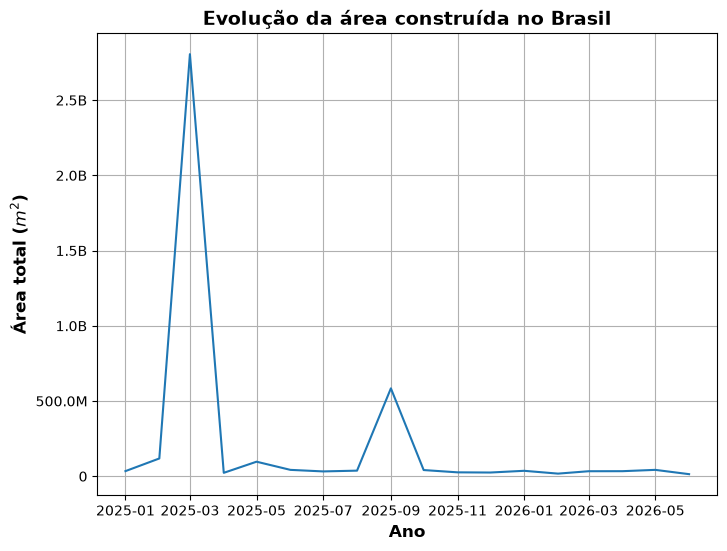

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df_cno_pivot[df_cno_pivot['Date'] >= pd.Timestamp(2025, 1, 1)]['Date'],
        df_cno_pivot[df_cno_pivot['Date'] >= pd.Timestamp(2025, 1, 1)]['m2'])
formatador = FuncFormatter(formatar_escala)
ax.yaxis.set_major_formatter(formatador)
ax.set_xlabel('Ano', fontsize=12, fontweight='bold')
ax.set_ylabel('Área total ($m^2$)', fontsize=12, fontweight='bold')
ax.set_title('Evolução da área construída no Brasil', fontsize=14, fontweight='bold')
ax.grid()

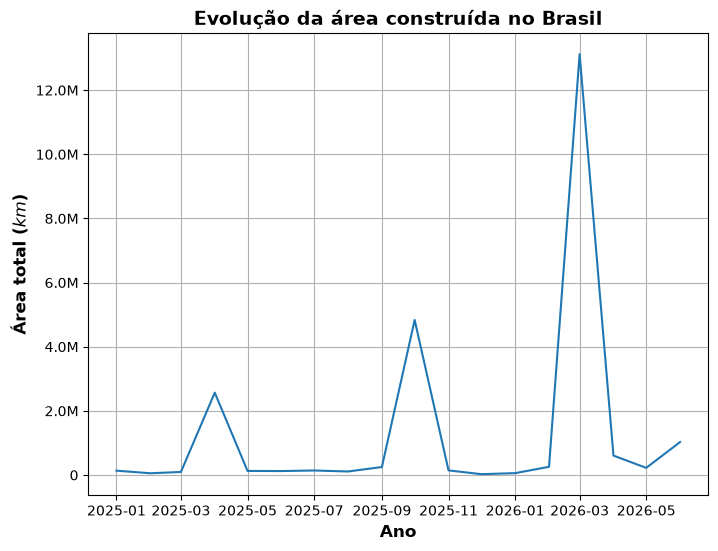

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df_cno_pivot[df_cno_pivot['Date'] >= pd.Timestamp(2025, 1, 1)]['Date'],
        df_cno_pivot[df_cno_pivot['Date'] >= pd.Timestamp(2025, 1, 1)]['km'])
formatador = FuncFormatter(formatar_escala)
ax.yaxis.set_major_formatter(formatador)
ax.set_xlabel('Ano', fontsize=12, fontweight='bold')
ax.set_ylabel('Área total ($km$)', fontsize=12, fontweight='bold')
ax.set_title('Evolução da área construída no Brasil', fontsize=14, fontweight='bold')
ax.grid()